Plot the simulation data of the current simulation for a comparison

In [30]:
# Import the simulation data saved in the excel file

import os
import pandas as pd
import numpy as np

CASE_ID = "C0002"
CASE_NAME = "C0002R01_PARK25_LC_1D_VAL"

PROJECT_ROOT = os.path.abspath("../..")

file_name = os.path.join(PROJECT_ROOT, "data", CASE_ID, f'{CASE_NAME}.xlsx')

df = pd.read_excel(file_name)

time_s = df.iloc[:,0].values
num_time_steps = len(time_s)

seg_num = 20

T_bat_history = df.iloc[:,1:seg_num+1].values
T_cool_history = df.iloc[:,seg_num+1:seg_num*2+1].values


In [31]:
# import the AC BTMS's results for comparison

CASE_ID_AC = "C0016"
CASE_NAME_AC = "C0016R00_PARK25_AC_THERM_1D_VAL"

file_name = os.path.join(PROJECT_ROOT, "data", CASE_ID_AC, f'{CASE_NAME_AC}.xlsx')
df_ac = pd.read_excel(file_name)

time_s_ac = df_ac.iloc[:,0].values
num_time_steps_ac = len(time_s_ac)

seg_num_ac = 20

T_bat_history_ac = df_ac.iloc[:,1:seg_num_ac+1].values
T_cool_history_ac = df_ac.iloc[:,seg_num_ac+1:seg_num_ac*2+1].values

In [43]:
# A simple comparison analysis

Tmax_LC = np.max(T_bat_history, axis=1)
Tmin_LC = np.min(T_bat_history, axis=1)

# Cut the last to align with the AC data
Tmax_LC = Tmax_LC[:-1]
Tmin_LC = Tmin_LC[:-1]
time_s = time_s[:-1]
DeltaT_LC = Tmax_LC - Tmin_LC

# Twater_out_1D = T_cool_history[:, -1]

Tmax_AC = np.max(T_bat_history_ac, axis=1)
Tmin_AC = np.min(T_bat_history_ac, axis=1)
DeltaT_AC = Tmax_AC - Tmin_AC

# output key information for the LC model
print(f'Tmax_mission_LC_H = {np.max(Tmax_LC):.4f} degC')
print(f'Tmax_mission_LC_C = {np.max(Tmin_LC):.4f} degC')
print(f'DeltaT_max_LC = {np.max(DeltaT_LC):.4f} degC')

# output key information for the AC model
print(f'Tmax_mission_AC_H = {np.max(Tmax_AC):.4f} degC')
print(f'Tmax_mission_AC_C = {np.max(Tmin_AC):.4f} degC')
print(f'DeltaT_max_AC = {np.max(Tmax_AC - Tmin_AC):.4f} degC')


print(f'temperature rise of AC with respect to LC at the hottest point = {np.max(Tmax_AC - Tmax_LC):.4f} degC')
print(f'temperature rise of AC with respect to LC at the coldest point = {np.max(Tmin_AC - Tmin_LC):.4f} degC')


Tmax_mission_LC_H = 37.5432 degC
Tmax_mission_LC_C = 36.1980 degC
DeltaT_max_LC = 1.3453 degC
Tmax_mission_AC_H = 47.9065 degC
Tmax_mission_AC_C = 45.7467 degC
DeltaT_max_AC = 2.1684 degC
temperature rise of AC with respect to LC at the hottest point = 10.3633 degC
temperature rise of AC with respect to LC at the coldest point = 9.5487 degC


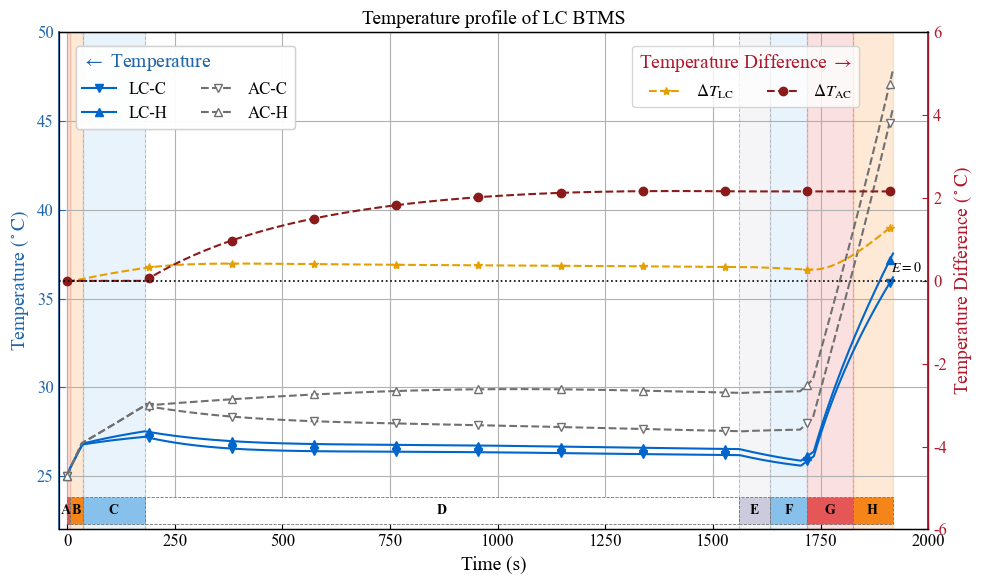

In [42]:
# plot the battery temperature over time
import matplotlib.pyplot as plt
from pyparsing import line
from matplotlib.patches import Rectangle
from matplotlib.transforms import blended_transform_factory

font_size = 12  # set the font size for the plot
t_park = [6, 36, 180, 1560, 1632, 1719, 1824, 1917]

stages = [
    'A: Take-off',
    'B: Ascent Transition',
    'C: Acceleration',
    'D: Cruise',
    'E: Deceleration',
    'F: Descent Transition',
    'G: Hovering',
    'H: Landing'
]  # corresponding stages for Park's experimental data

# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': font_size,
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})


plt.figure(figsize=(10, 6))
# plt.plot(T_bat, label='T_bat (wo. cooling)(°C)')
# plot the battery temperature under air cooling as a dashed line
# plt.plot(T_bat_0D, label='T_bat,0D (°C)', linestyle='-.')

# plot the air outlet temperature profile for analysis
# plt.plot(T_air_out_0D, label='T_air,out, 0D (°C)', linestyle=':') # convert to Celsius for plotting


stages_bgcolors = ['#E45756','#F58518', "#87c1eb", "#FFFFFF", "#CBCBDD", '#87c1eb', '#E45756', '#F58518']  # background colors for each stage in the flight profile


# get the primary y-axis for plotting the battery temperature and air outlet temperature
ax1 = plt.gca()  # get the current axes for plotting the battery temperature and air outlet temperature

ax1.set_xlim(-20, 2000)  # set the x-axis limits based on the number of time steps
ax1.set_ylim(22, 50)
alpha_band = 0.18
# get the colormap 'Pastel1' of Matplotlib to use for the background colors of each stage in the flight profile
cmap = plt.get_cmap('Set3')
# plot the band for each stage with the specified background color
for i in range(len(t_park)):
    if i == 0:
        ax1.axvspan(0, t_park[i], color=stages_bgcolors[i], alpha=alpha_band, zorder=0)  # background color for each stage
    else:
        ax1.axvspan(t_park[i-1], t_park[i], color=stages_bgcolors[i], alpha=alpha_band, zorder=0)  # background color for each stage
    # plt.axvspan(t_park[i], t_park[i+1], color=cmap(i % cmap.N), alpha=0.4)  # background color for each stage

# Optional vertical boundaries
for boundary in t_park[1:-1]:
    ax1.axvline(
        boundary,
        color="0.65",
        linewidth=0.7,
        linestyle="--",
        alpha=0.7,
        zorder=1
    )

# x coordinate: data coordinates
# y coordinate: axes coordinates
trans = blended_transform_factory(ax1.transData, ax1.transAxes)

bar_bottom = 0.01
bar_height = 0.055

for i, name in enumerate(stages):
    t_start = 0 if i == 0 else t_park[i - 1]
    t_end = t_park[i]
    t_mid = (t_start + t_end) / 2
    duration = t_end - t_start

    offset = 5 if i == 0 else 0.0
    
    # Colored rectangle
    rect = Rectangle(
        (t_start, bar_bottom),
        duration,
        bar_height,
        transform=trans,
        facecolor=stages_bgcolors[i],
        edgecolor="0.45",
        linewidth=0.6,
        linestyle="--",
        clip_on=False,
        zorder=10,
        alpha=1.0
    )
    ax1.add_patch(rect)

    label = name.split(":")[0]  # Use the first part of the stage name for labeling
    
    # Full names can be shown horizontally in wide stages.
    # Use only S1, S2, ... in narrow stages.
    if duration >= 180:
        rotation = 0
        fontsize = font_size-2
    else:
        # label = name.split(":")[0]  # use only the first letter of the stage name for narrow stages
        rotation = 0
        fontsize = font_size-2

    ax1.text(
        t_mid-offset,
        bar_bottom + bar_height / 2,
        label,
        transform=trans,
        ha="center",
        va="center",
        rotation=rotation,
        fontsize=fontsize,
        fontweight='bold',
        color="black",
        clip_on=False,
        zorder=11
    )

mark_number = 10
mark_spacing = len(time_s) // mark_number  # calculate the spacing for markers based on the number of data points and desired number of markers

# Left y-axis: temperature
left_style = {
    "Park":    dict(label='Park', color="#8E44AD", ls="-", marker="o"),
    "CFD_AVG": dict(label='CFD', color="#707070", ls="-", marker="x"),
    "AC_MIN": dict(label='AC-C', color="#707070", ls="--", marker="v",
                    markerfacecolor="white"),
    "AC_MAX": dict(label='AC-H', color="#707070", ls="--", marker="^",
                    markerfacecolor="white"),
    "LC_MIN":  dict(label='LC-C', color="#0066CC", ls="-", marker="v"),
    "LC_MAX":  dict(label='LC-H', color="#0066CC", ls="-", marker="^"),
}

# Right y-axis: temperature error
right_style = {
    "CFD_MIN": dict(label='CFD-C', color="#E69F00", ls="--", marker="*",
                    markerfacecolor="white"),
    "CFD_MAX": dict(label='CFD-H', color="#D55E00", ls="--", marker="o",
                    markerfacecolor="white"),
    "dT_LC":  dict(label=r'$\Delta T_\mathrm{LC}$', color="#E69F00", ls="--", marker="*"),
    "dT_AC":  dict(label=r'$\Delta T_\mathrm{AC}$', color="#8B1A1A", ls="--", marker="o"),
}

left_color = "#2166AC"
right_color = "#B2182B"


# first axis for temperature profile

line_style = left_style[f'LC_MIN']
ax1.plot(
    time_s, 
    Tmin_LC, 
    **line_style,
    markevery=mark_spacing) # plot the minimum battery temperature across segments as a dotted line

line_style = left_style[f'LC_MAX']
ax1.plot(
    time_s, 
    Tmax_LC, 
    **line_style,
    markevery=mark_spacing) # plot the maximum battery temperature across segments as a dotted line

line_style = left_style[f'AC_MIN']
ax1.plot(
    time_s, 
    Tmin_AC, 
    **line_style,
    markevery=mark_spacing) # plot the minimum battery temperature across segments as a dotted line

line_style = left_style[f'AC_MAX']
ax1.plot(
    time_s, 
    Tmax_AC, 
    **line_style,
    markevery=mark_spacing) # plot the maximum battery temperature across segments as a dotted line

# secondary axis for plotting the temperature difference between the hottest and coldest segments of LC and AC BTMS

ax2 = ax1.twinx()  # create a twin y-axis for plotting the temperature difference between the 1D simulation and Park's experimental data

# set the limits for the twin y-axis based on the range of temperature differences
ax2.set_ylim(-6, 6)  # set the limits for the twin y-axis based on the range of temperature differences


marker_spacing = len(time_s) // mark_number  # calculate the spacing for markers based on the number of data points and desired number of markers

line_style = right_style['dT_LC']
ax2.plot(
    time_s, 
    DeltaT_LC,     
    **line_style,
    markevery=marker_spacing)  # plot the temperature difference for the minimum battery temperature

line_style = right_style['dT_AC']
ax2.plot(
    time_s, 
    DeltaT_AC, 
    **line_style, 
    markevery=marker_spacing)  # plot the temperature difference for the maximum battery temperature

ax2.axhline(0, color='black', linestyle=':', linewidth=1.2)  # plot a horizontal line at y=0 for reference  
ax2.annotate(
    r"$E=0$",
    xy=(1.0, 0),
    xycoords=("axes fraction", "data"),
    xytext=(-5, 4),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=font_size-2,
    color="0"
)

ax1.set_xlabel('Time (s)', fontsize=font_size+2)
ax1.set_ylabel(r"Temperature ($^\circ\mathrm{C}$)", color=left_color, fontsize=font_size+2)
ax1.tick_params(axis="y", colors=left_color)
ax1.spines["left"].set_color(left_color)
ax1.spines["left"].set_linewidth(1.3)

ax2.set_ylabel(r"Temperature Difference ($^\circ\mathrm{C}$)", color=right_color, fontsize=font_size+2)
ax2.tick_params(axis="y", colors=right_color)
ax2.spines["right"].set_color(right_color)
ax2.spines["right"].set_linewidth(1.3)

ax1.set_title('Temperature profile of LC BTMS', fontsize=font_size+2)

handles_left, labels_left = ax1.get_legend_handles_labels()  # get the handles and labels for the primary y-axis legend

# handle_order = [3, 0, 4, 5, 2, 1]  # specify the order of the legend entries for the primary y-axis legend
# handles_left = [handles_left[i] for i in handle_order]
# labels_left = [labels_left[i] for i in handle_order]

handles_right, labels_right = ax2.get_legend_handles_labels()  # get the handles and labels for the secondary y-axis legend

leg1 = ax1.legend(
    handles_left,
    labels_left,
    # title="Temperature - left axis",    
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=2,
    # labelcolor=left_color,
    fontsize=font_size,
    alignment='left'
)
leg1.set_title(r"$\leftarrow$ Temperature", prop={"size": font_size+2})
leg1.get_title().set_color(left_color)


leg2 = ax2.legend(
    handles_right,
    labels_right,
    # title="Temperature Difference - right axis",
    # labelcolor=right_color,
    loc="upper right",
    bbox_to_anchor=(0.93, 0.99),
    ncol=2,
    fontsize=font_size,
    alignment='right'
)
leg2.set_title(r"Temperature Difference $\rightarrow$", prop={"size": font_size+2})
leg2.get_title().set_color(right_color)

ax1.add_artist(leg1)

ax1.grid()

plt.tight_layout()

# save the plot as a vector graphic (SVG) and a high-resolution PNG for publication purposes
plot_file_name = os.path.join(PROJECT_ROOT, 'out', CASE_ID, f'{CASE_NAME}.pdf')

if(not os.path.exists(os.path.dirname(plot_file_name))):
    os.makedirs(os.path.dirname(plot_file_name))

plt.savefig(
    plot_file_name,
    dpi=600,
    bbox_inches='tight'
)

# also save one to the paper's working directory

paper_wd = r"D:\Workspace\Paper_eBATS\images"

plt.savefig(
    os.path.join(paper_wd, f'{CASE_NAME}.pdf'),
    dpi=600,
    bbox_inches='tight'
)


plt.show()

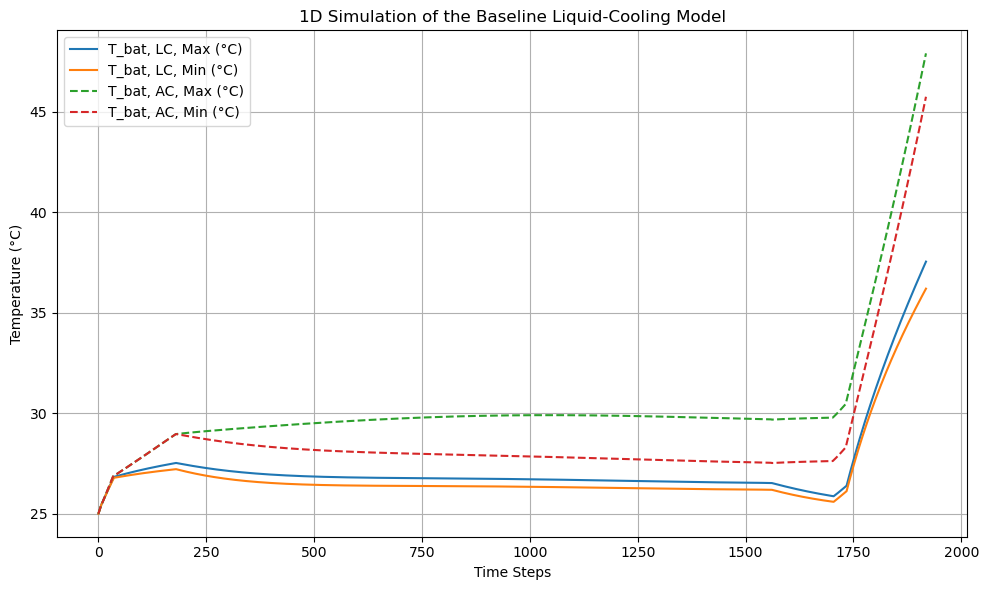

Tmax_mission_LC_H = 37.5432 degC
Tmax_mission_LC_C = 36.1980 degC
DeltaT_max_LC = 1.3453 degC
Twater_out_max = 27.9932 degC
Saved figure: d:\Workspace\eBATS\out\C0002\C0002R01_PARK25_LC_1D_VAL.pdf


In [18]:
# calculate indicators and save the temperature figure
import matplotlib.pyplot as plt



RESULT_FIGURE_PATH = os.path.join(PROJECT_ROOT, "out", CASE_ID, f'{CASE_NAME}.pdf')

# Use the same plotting style as the reference BTMS T Solver notebook.
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
plt.plot(time_s, Tmax_LC, label='T_bat, LC, Max (°C)', linestyle='-')
plt.plot(time_s, Tmin_LC, label='T_bat, LC, Min (°C)', linestyle='-')
# plt.plot(time_s, Twater_out_1D, label='T_water,out, 1D (°C)', linestyle=':')

plt.plot(time_s, Tmax_AC, label='T_bat, AC, Max (°C)', linestyle='--')
plt.plot(time_s, Tmin_AC, label='T_bat, AC, Min (°C)', linestyle='--')

plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.title('1D Simulation of the Baseline Liquid-Cooling Model')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    RESULT_FIGURE_PATH,
    dpi=600,
    bbox_inches='tight'
)
plt.show()

print(f'Tmax_mission_LC_H = {np.max(Tmax_LC):.4f} degC')
print(f'Tmax_mission_LC_C = {np.max(Tmin_LC):.4f} degC')
print(f'DeltaT_max_LC = {np.max(DeltaT_LC):.4f} degC')
print(f'Twater_out_max = {np.max(Twater_out_1D):.4f} degC')
print(f'Saved figure: {RESULT_FIGURE_PATH}')
